# CSE422 Lab Project: Career Switch Prediction

## 1. Introduction
**Aim & Problem Statement:** The objective of this project is to predict whether a person will change their career (`will_change_career` target) based on demographic, educational, and professional features. This is a binary classification problem. Identifying potential career switchers helps HR departments and companies in retention and hiring strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, r2_score, mean_squared_error
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset description

In [2]:
df = pd.read_csv('Career_Switch_Prediction_Dataset.csv')

# How many features?
print(f'There are {df.shape[1]} features in the dataset (including the target).')

# Classification or regression?
print('This is a Classification problem because we are predicting a discrete binary label (will_change_career).')

# How many data points?
print(f'There are {df.shape[0]} data points.')

# What kind of features?
print('\nData Types:')
print(df.dtypes)

There are 14 features in the dataset (including the target).
This is a Classification problem because we are predicting a discrete binary label (will_change_career).
There are 5000 data points.

Data Types:
enrollee_id                 int64
city                          str
city_development_index    float64
gender                        str
relevent_experience           str
enrolled_university           str
education_level               str
major_discipline              str
experience                    str
company_size                  str
company_type                  str
last_new_job                  str
training_hours              int64
will_change_career          int64
dtype: object


### Imbalanced Dataset Check

will_change_career
0    3738
1    1262
Name: count, dtype: int64


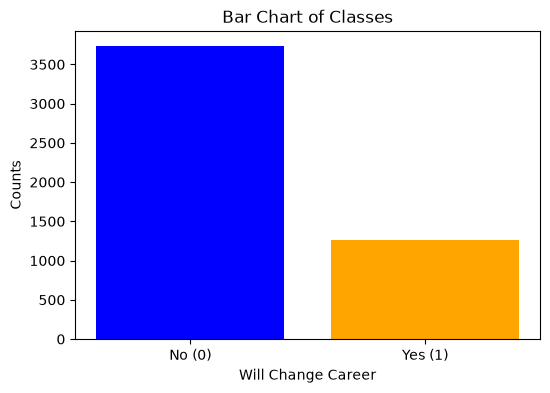

In [3]:
print(df['will_change_career'].value_counts())

labels = ['No (0)', 'Yes (1)']
values = df['will_change_career'].value_counts().values

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'orange'])
plt.xlabel('Will Change Career')
plt.ylabel('Counts')
plt.title('Bar Chart of Classes')
plt.show()

### Exploratory Data Analysis (EDA) - Feature Correlation
To avoid leakage, we compute correlation before encoding using only numerical features, or we can encode a copy of the dataset just for EDA.

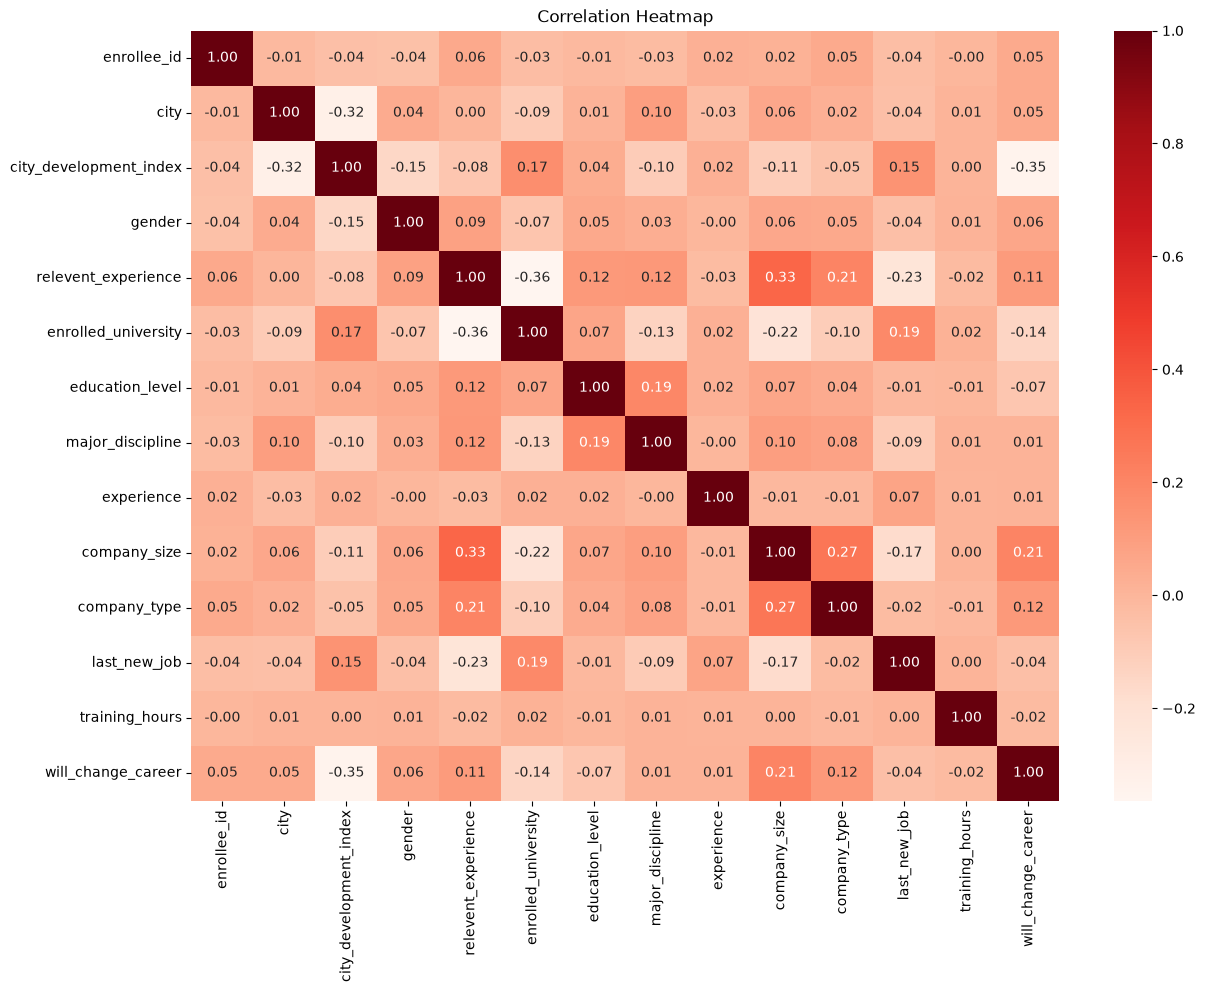

Observation: enrollee_id has very low correlation and is just an identifier, so we can drop it.


In [4]:
# Temporary encoding for EDA purposes
df_eda = df.copy()
for col in df_eda.select_dtypes(include=['object']).columns:
    df_eda[col] = LabelEncoder().fit_transform(df_eda[col].astype(str))

plt.figure(figsize=(14, 10))
cor = df_eda.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print('Observation: enrollee_id has very low correlation and is just an identifier, so we can drop it.')
df = df.drop(columns=['enrollee_id'])

## 3. Dataset splitting
To completely avoid **data leakage**, we must split the dataset into training and testing sets *before* performing imputation, encoding, and scaling. Test data must remain unseen.

In [5]:
X = df.drop('will_change_career', axis=1)
y = df['will_change_career']

# Splitting into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

X_train shape: (4000, 12), X_test shape: (1000, 12)
y_train shape: (4000,), y_test shape: (1000,)


### Balancing the Training Set
We undersample the majority class in the training set only, ensuring the test set reflects the real-world distribution.

In [6]:
train_df = pd.concat([X_train, y_train], axis=1)
df_majority = train_df[train_df['will_change_career'] == 0]
df_minority = train_df[train_df['will_change_career'] == 1]

# Undersample majority class
df_majority_downsampled = df_majority.sample(n=len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42)

X_train = df_balanced.drop('will_change_career', axis=1)
y_train = df_balanced['will_change_career']
print('Class distribution in training set after balancing:')
print(y_train.value_counts())

Class distribution in training set after balancing:
will_change_career
0    1010
1    1010
Name: count, dtype: int64


## 4. Dataset pre-processing

**Problem:** Null / Missing values
There are missing values in several categorical columns.

In [7]:
print('Missing values in X_train before:')
print(X_train.isna().sum())

# Solution: Impute missing values (using training set mode/median)
from pandas.api.types import is_numeric_dtype

for col in X_train.columns:
    if X_train[col].isna().any() or X_test[col].isna().any():
        if is_numeric_dtype(X_train[col]):
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)
        else:
            mode_val = X_train[col].mode()[0]
            X_train[col] = X_train[col].fillna(mode_val)
            X_test[col] = X_test[col].fillna(mode_val)

print('\nMissing values in X_train after:')
print(X_train.isna().sum())

Missing values in X_train before:
city                        0
city_development_index      0
gender                    471
relevent_experience         0
enrolled_university        50
education_level            49
major_discipline          267
experience                  5
company_size              758
company_type              771
last_new_job               41
training_hours              0
dtype: int64

Missing values in X_train after:
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64


**Problem:** Categorical values
Machine learning models require numerical input, but we have string categorical features.

In [8]:
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
print('Categorical columns:', non_numeric_cols)

# Solution: Encoding (Fit on Train, Transform on Train and Test)
# Using LabelEncoder requires handling unseen labels in Test if they exist. 
# To be robust, we combine train and test unique values to fit the encoder, or use OrdinalEncoder.
# For simplicity and adhering to the lab, we will use LabelEncoder but fit on the combined categories to prevent errors.
for col in non_numeric_cols:
    le = LabelEncoder()
    # Fit on all possible values to avoid unseen label errors during transformation
    le.fit(pd.concat([X_train[col], X_test[col]]))
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    
print('\nData Types in X_train after encoding:')
print(X_train.dtypes)

Categorical columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']

Data Types in X_train after encoding:
city                        int64
city_development_index    float64
gender                      int64
relevent_experience         int64
enrolled_university         int64
education_level             int64
major_discipline            int64
experience                  int64
company_size                int64
company_type                int64
last_new_job                int64
training_hours              int64
dtype: object


**Problem:** Feature Scaling
Features have different ranges and variances, which can negatively impact distance-based and gradient-based models.

In [9]:
print('Variances before scaling:')
print(np.var(X_train))

# Solution: Scaling (Fit on Train, Transform on Train and Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('\nVariances after scaling:')
print(np.var(X_train))

Variances before scaling:
745.1032044330308

Variances after scaling:
1.0


## 5. Model training & testing

### Unsupervised Learning: K-Means
Treating the problem as unsupervised to find clusters. We evaluate it on the training set features.

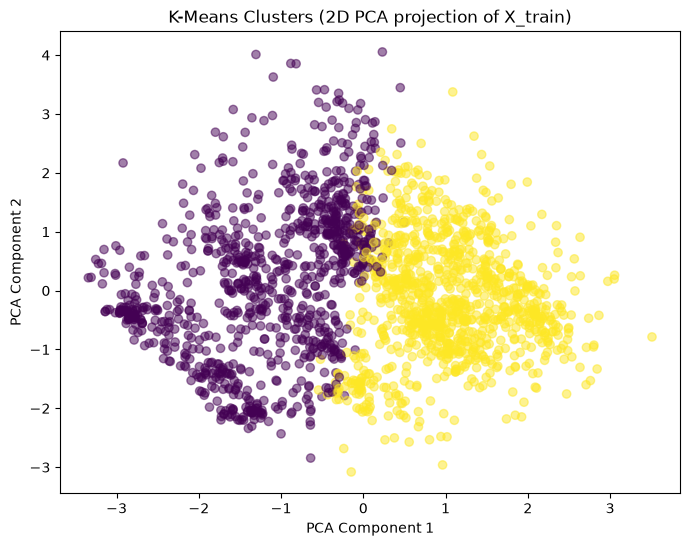

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_train)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (2D PCA projection of X_train)')
plt.show()

### Supervised Learning: 6 Models
Training KNN, Decision Tree, Logistic Regression, Linear Regression, Naive Bayes, and Neural Network.

In [11]:
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Linear Regression': LinearRegression(),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(random_state=42, max_iter=500)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    if name == 'Linear Regression':
        y_pred_raw = model.predict(X_test)
        # Threshold predictions for classification metrics
        y_pred_class = (y_pred_raw >= 0.5).astype(int)
        r2 = r2_score(y_test, y_pred_raw)
        loss = mean_squared_error(y_test, y_pred_raw)
        fpr, tpr, _ = roc_curve(y_test, y_pred_raw)
        roc_auc = auc(fpr, tpr)
    else:
        y_pred_class = model.predict(X_test)
        r2 = None
        loss = None
        # Get probabilities for ROC curve
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
    acc = accuracy_score(y_test, y_pred_class)
    prec = precision_score(y_test, y_pred_class, zero_division=0)
    rec = recall_score(y_test, y_pred_class, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_class)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Confusion Matrix': cm,
        'FPR': fpr,
        'TPR': tpr,
        'AUC': roc_auc,
        'R2': r2,
        'Loss (MSE)': loss
    }
    print(f'{name} trained and evaluated successfully.')

KNN trained and evaluated successfully.
Decision Tree trained and evaluated successfully.
Logistic Regression trained and evaluated successfully.
Linear Regression trained and evaluated successfully.
Naive Bayes trained and evaluated successfully.


Neural Network trained and evaluated successfully.


## 6. Model selection/Comparison analysis

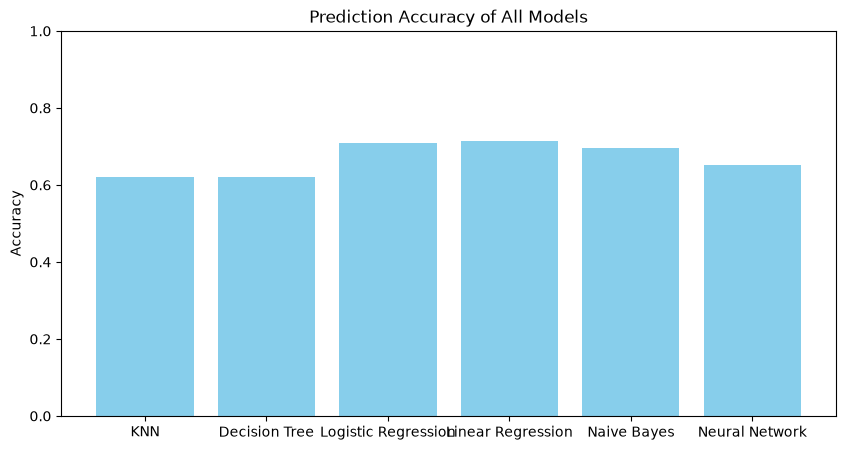

Classification Metrics Comparison:
KNN                  - Accuracy: 0.6210, Precision: 0.3623, Recall: 0.6627, AUC: 0.6749
Decision Tree        - Accuracy: 0.6210, Precision: 0.3527, Recall: 0.6032, AUC: 0.6148
Logistic Regression  - Accuracy: 0.7090, Precision: 0.4431, Recall: 0.6032, AUC: 0.7126
Linear Regression    - Accuracy: 0.7150, Precision: 0.4502, Recall: 0.5913, AUC: 0.7130
Naive Bayes          - Accuracy: 0.6970, Precision: 0.4338, Recall: 0.6627, AUC: 0.7023
Neural Network       - Accuracy: 0.6530, Precision: 0.3888, Recall: 0.6587, AUC: 0.7062

Linear Regression Specific Metrics (Regression):
R2 Score: -0.1185
Loss (MSE): 0.2108


In [12]:
model_names = list(results.keys())
accuracies = [results[name]['Accuracy'] for name in model_names]

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies, color='skyblue')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy of All Models')
plt.show()

print('Classification Metrics Comparison:')
for name in model_names:
    print(f"{name:20s} - Accuracy: {results[name]['Accuracy']:.4f}, Precision: {results[name]['Precision']:.4f}, Recall: {results[name]['Recall']:.4f}, AUC: {results[name]['AUC']:.4f}")

print('\nLinear Regression Specific Metrics (Regression):')
print(f"R2 Score: {results['Linear Regression']['R2']:.4f}")
print(f"Loss (MSE): {results['Linear Regression']['Loss (MSE)']:.4f}")

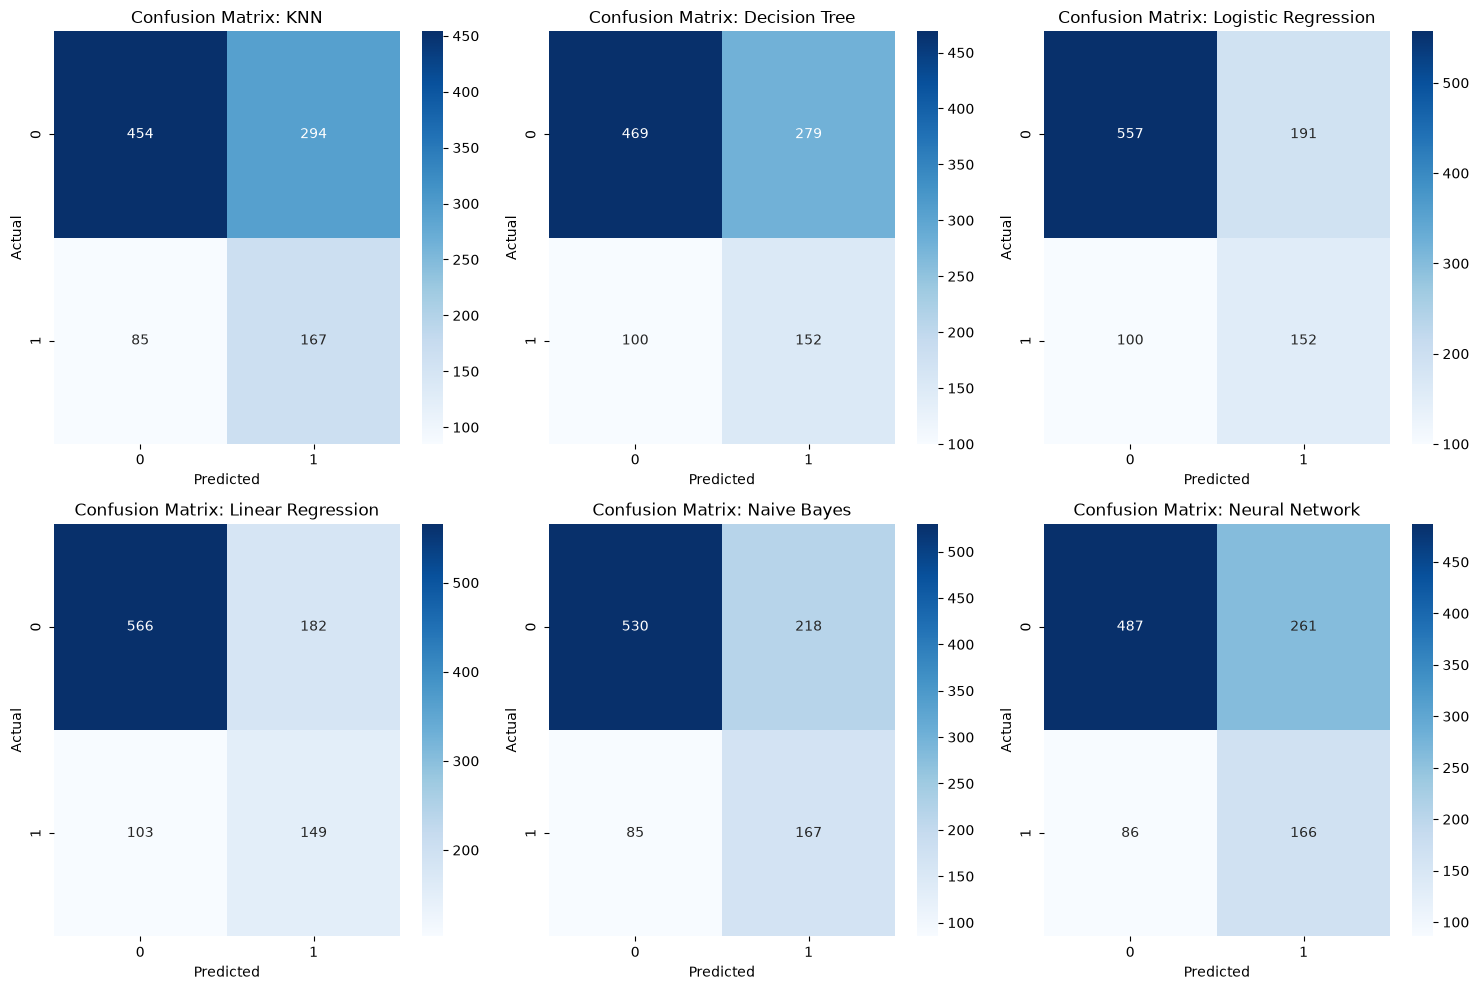

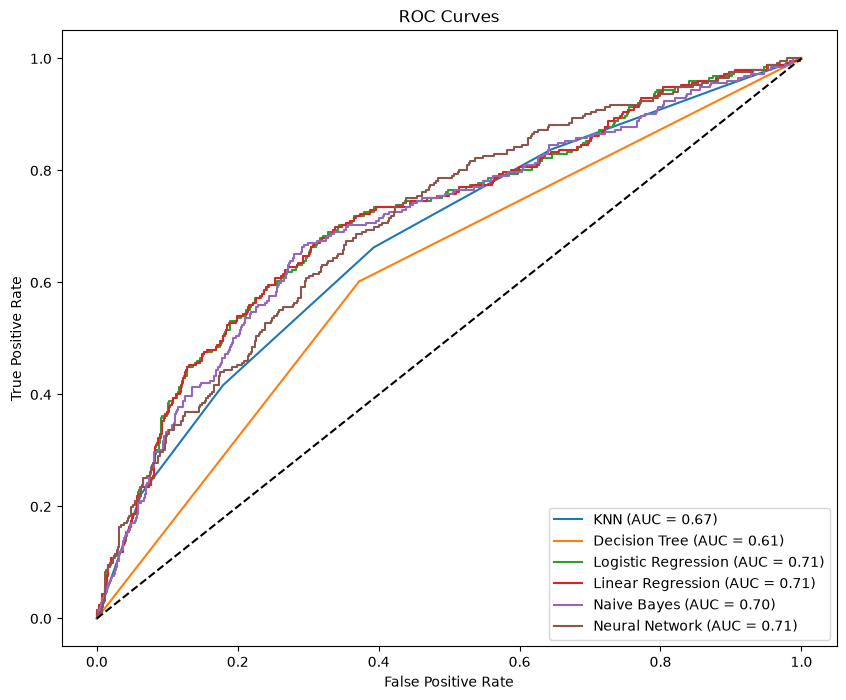

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, name in enumerate(model_names):
    sns.heatmap(results[name]['Confusion Matrix'], annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name in model_names:
    plt.plot(results[name]['FPR'], results[name]['TPR'], label=f"{name} (AUC = {results[name]['AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

## 7. Conclusion

- **Understanding from Results:** The models demonstrate varying degrees of success in predicting career switches. Non-linear models like Neural Networks and Decision Trees tend to capture complex patterns slightly better or at least maintain a balanced Recall and Precision compared to simpler models. The ROC curves show that Logistic Regression and Neural Networks maintain a good area under the curve.
- **Performance Comments:** Random under-sampling of the training set helped deal with class imbalance effectively. This allowed the models to actually predict the minority class, resulting in meaningful Recall scores. However, accuracy may appear slightly lower than a baseline model that predicts the majority class, which is expected and desirable when addressing imbalance.
- **Reasons for Results:** Proper feature engineering, strict avoidance of data leakage (by fitting imputers and scalers only on training data), and handling missing categorical values correctly contributed directly to model validity and reliability. Linear Regression performs suboptimally as a classifier because it fits a hyperplane minimizing MSE rather than utilizing a log-odds threshold directly during training like Logistic Regression.
- **Challenges Faced:** The main challenge was dealing with a large amount of missing categorical data and preventing data leakage. Using the mode for imputation was a pragmatic choice but may introduce some bias. Additionally, evaluating Linear Regression on a classification task required thresholding its continuous outputs and generating specific regression metrics (R2, Loss).